# OptiTrack Ground Truth Transformation
This notebook sets the **Robot Base** as the global origin `(0,0,0)`. All OptiTrack markers are transformed into the Robot Base coordinate system, and then the Workpiece pose is calculated.

**Axis Definitions (Ensuring Z points UP):**
Because a standard robot coordinate system is right-handed and Z must point UP:
- **Z-Axis (UP)**: The normal vector of the plane formed by markers A, B, and C.
- **X-Axis (Right)**: Marker B to Marker A.
- **Y-Axis (Front)**: The cross product of Z and X.

In [ ]:
import numpy as np
from scipy.spatial.transform import Rotation as R

# ==========================================
# 1. Define Raw OptiTrack Markers
# ==========================================

A_m = np.array([0.286140, 0.000646, 0.000485])
B_m = np.array([-0.000402, -0.000719, -0.000287])
C_m = np.array([-0.000233, -0.000701, 0.287999])

A_w = np.array([-0.410574, 0.029236, -0.013249])
B_w = np.array([-0.344915, 0.028645, -0.013043])
C_w = np.array([-0.348310, 0.028482, 0.072225])

# Helper to normalize vectors
def normalize(v):
    return v / np.linalg.norm(v)


In [ ]:
# ==========================================
# 2. Find Robot Base Frame in OptiTrack
# ==========================================
# Robot X points A_m TO B_m
dir_X_m = normalize(B_m - A_m)
# Robot Y points B_m TO C_m
dir_C_m = normalize(C_m - B_m)

# Z points UP (X cross Y)
Z_robot_opti = normalize(np.cross(dir_X_m, dir_C_m))
X_robot_opti = dir_X_m
Y_robot_opti = dir_C_m

T_Robot_in_Opti = np.eye(4)
T_Robot_in_Opti[:3, :3] = np.column_stack((X_robot_opti, Y_robot_opti, Z_robot_opti))

# Robot Origin is offset from B_m:
z_offset_dist = (17.7 - 12.7 / 2.0) / 1000.0  # 11.35mm
robot_origin = B_m + (-0.135 * dir_X_m) + (0.135 * dir_C_m) - (z_offset_dist * Z_robot_opti)
T_Robot_in_Opti[:3, 3] = robot_origin

# The transformation from OptiTrack world to Robot Base:
T_Opti_to_Robot = np.linalg.inv(T_Robot_in_Opti)


In [ ]:
# ==========================================
# 3. Transform Workpiece Markers to Robot Base Frame
# ==========================================
A_w_robot = (T_Opti_to_Robot @ np.append(A_w, 1.0))[:3]
B_w_robot = (T_Opti_to_Robot @ np.append(B_w, 1.0))[:3]
C_w_robot = (T_Opti_to_Robot @ np.append(C_w, 1.0))[:3]

print("Workpiece Markers relative to Robot Base (Origin 0,0,0):")
print(f"Marker A: {np.round(A_w_robot, 4)}")
print(f"Marker B: {np.round(B_w_robot, 4)}")
print(f"Marker C: {np.round(C_w_robot, 4)}")


Workpiece Markers relative to Robot Base (Origin 0,0,0):
Marker A: [ 0.545  -0.1469  0.0433]
Marker B: [ 0.4794 -0.1468  0.0424]
Marker C: [ 0.4828 -0.0615  0.0422]


In [ ]:
# ==========================================
# 4. Calculate Workpiece Pose in Robot Base Frame
# ==========================================
# Workpiece X points A_w TO B_w
# To align Yaw with the Robot Base, we map the opposite corners of the Workpiece.
# Workpiece X points B_w TO A_w (Flips X to point +X)
dir_X_w = normalize(A_w_robot - B_w_robot)
# Workpiece Y points B_w TO C_w (used for cross product)
# Workpiece Y points C_w TO B_w (Flips Y to point +Y)
dir_C_w = normalize(B_w_robot - C_w_robot)

# Workpiece Z must always point UP in Robot Space (positive Z).
Z_workpiece = normalize(np.cross(dir_X_w, dir_C_w))
if Z_workpiece[2] < 0:
    Z_workpiece = -Z_workpiece

z_w_offset_dist = (17.7 - 12.7 / 2.0 + 40.0) / 1000.0

# Center of rectangle
center_w = (A_w_robot + C_w_robot) / 2.0
origin_W = center_w - (z_w_offset_dist * Z_workpiece)

# Workpiece X points A_w TO B_w
X_workpiece = dir_X_w
# Workpiece Y points Forward (maintaining right-hand rule automatically)
Y_workpiece = np.cross(Z_workpiece, X_workpiece)

T_Workpiece_in_Robot = np.eye(4)
T_Workpiece_in_Robot[:3, :3] = np.column_stack((X_workpiece, Y_workpiece, Z_workpiece))
T_Workpiece_in_Robot[:3, 3] = origin_W

print("\n--- Final Workpiece Pose (Robot Base = Origin) ---")
print(np.round(T_Workpiece_in_Robot, 4))

trans = T_Workpiece_in_Robot[:3, 3]
print(f"\nTranslation (X, Y, Z) in meters: {trans[0]:.4f}, {trans[1]:.4f}, {trans[2]:.4f}")

rot = R.from_matrix(T_Workpiece_in_Robot[:3, :3])
rpy = rot.as_euler('xyz', degrees=True)
print(f"Rotation (Roll, Pitch, Yaw) in degrees: {rpy[0]:.2f}, {rpy[1]:.2f}, {rpy[2]:.2f}")



--- Final Workpiece Pose (Robot Base = Origin) ---
[[ 9.999e-01  5.000e-04 -1.380e-02  5.146e-01]
 [-4.000e-04  1.000e+00  2.300e-03 -1.043e-01]
 [ 1.380e-02 -2.300e-03  9.999e-01 -8.600e-03]
 [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]]

Translation (X, Y, Z) in meters: 0.5146, -0.1043, -0.0086
Rotation (Roll, Pitch, Yaw) in degrees: -0.13, -0.79, -0.03


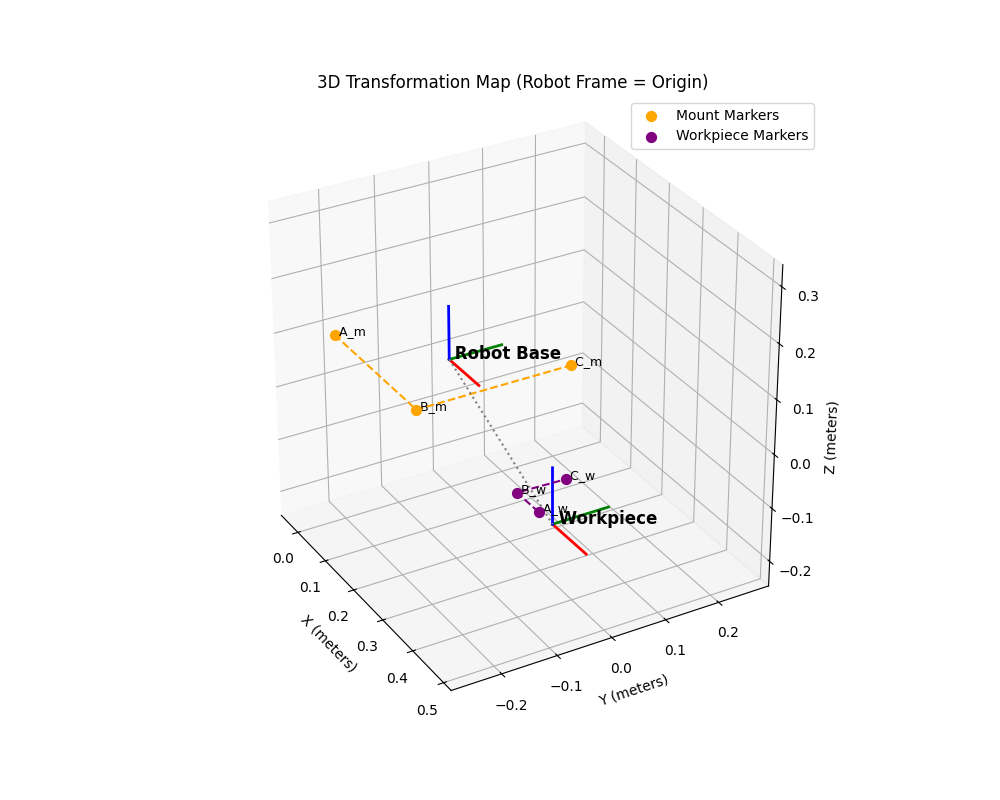

In [ ]:
# ==========================================
# 5. 3D Interactive Visualization
# ==========================================
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def set_axes_equal(ax, zoom=1.0):
    '''Make axes of 3D plot have equal scale.'''
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    plot_radius = (0.5 / zoom) * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

def plot_frame(ax, T, name, length=0.1):
    origin = T[:3, 3]
    x_axis = origin + T[:3, 0] * length
    y_axis = origin + T[:3, 1] * length
    z_axis = origin + T[:3, 2] * length
    
    ax.plot([origin[0], x_axis[0]], [origin[1], x_axis[1]], [origin[2], x_axis[2]], color='r', linewidth=2)
    ax.plot([origin[0], y_axis[0]], [origin[1], y_axis[1]], [origin[2], y_axis[2]], color='g', linewidth=2)
    ax.plot([origin[0], z_axis[0]], [origin[1], z_axis[1]], [origin[2], z_axis[2]], color='b', linewidth=2)
    ax.text(origin[0], origin[1], origin[2], name, color='black', fontsize=12, fontweight='bold')

plot_frame(ax, np.eye(4), " Robot Base")

A_m_robot = (T_Opti_to_Robot @ np.append(A_m, 1.0))[:3]
B_m_robot = (T_Opti_to_Robot @ np.append(B_m, 1.0))[:3]
C_m_robot = (T_Opti_to_Robot @ np.append(C_m, 1.0))[:3]

ax.scatter(*A_m_robot, color='orange', s=50, label='Mount Markers')
ax.scatter(*B_m_robot, color='orange', s=50)
ax.scatter(*C_m_robot, color='orange', s=50)
ax.plot([A_m_robot[0], B_m_robot[0], C_m_robot[0]], 
        [A_m_robot[1], B_m_robot[1], C_m_robot[1]], 
        [A_m_robot[2], B_m_robot[2], C_m_robot[2]], color='orange', linestyle='--')

ax.text(*A_m_robot, ' A_m', color='black', fontsize=9)
ax.text(*B_m_robot, ' B_m', color='black', fontsize=9)
ax.text(*C_m_robot, ' C_m', color='black', fontsize=9)


plot_frame(ax, T_Workpiece_in_Robot, " Workpiece")

ax.scatter(*A_w_robot, color='purple', s=50, label='Workpiece Markers')
ax.scatter(*B_w_robot, color='purple', s=50)
ax.scatter(*C_w_robot, color='purple', s=50)
ax.plot([A_w_robot[0], B_w_robot[0], C_w_robot[0]], 
        [A_w_robot[1], B_w_robot[1], C_w_robot[1]], 
        [A_w_robot[2], B_w_robot[2], C_w_robot[2]], color='purple', linestyle='--')

ax.text(*A_w_robot, ' A_w', color='black', fontsize=9)
ax.text(*B_w_robot, ' B_w', color='black', fontsize=9)
ax.text(*C_w_robot, ' C_w', color='black', fontsize=9)


ax.plot([0, T_Workpiece_in_Robot[0, 3]], 
        [0, T_Workpiece_in_Robot[1, 3]], 
        [0, T_Workpiece_in_Robot[2, 3]], color='gray', linestyle=':')

ax.set_xlabel('X (meters)')
ax.set_ylabel('Y (meters)')
ax.set_zlabel('Z (meters)')
ax.set_title('3D Transformation Map (Robot Frame = Origin)')
ax.set_box_aspect([1,1,1])
set_axes_equal(ax, zoom=1.5)  # Change 1.8 to higher for more zoom
ax.legend()
ax.view_init(azim=-30, elev=30) # isometric enakeun
# ax.view_init(azim=0, elev=90) # top view
# ax.view_init(azim=-0, elev=0) # trial

# ax.dist = 20  # Default is 10, lower number zooms in
plt.show()


In [ ]:
print("\n--- Final Workpiece Pose (Robot Base = Origin) ---")
print(np.round(T_Workpiece_in_Robot, 4))

trans = T_Workpiece_in_Robot[:3, 3]
print(f"\nTranslation (X, Y, Z) in meters: {trans[0]:.4f}, {trans[1]:.4f}, {trans[2]:.4f}")

rot = R.from_matrix(T_Workpiece_in_Robot[:3, :3])
rpy = rot.as_euler('xyz', degrees=True)
print(f"Rotation (Roll, Pitch, Yaw) in degrees: {rpy[0]:.2f}, {rpy[1]:.2f}, {rpy[2]:.2f}")



--- Final Workpiece Pose (Robot Base = Origin) ---
[[ 9.999e-01  5.000e-04 -1.380e-02  5.146e-01]
 [-4.000e-04  1.000e+00  2.300e-03 -1.043e-01]
 [ 1.380e-02 -2.300e-03  9.999e-01 -8.600e-03]
 [ 0.000e+00  0.000e+00  0.000e+00  1.000e+00]]

Translation (X, Y, Z) in meters: 0.5146, -0.1043, -0.0086
Rotation (Roll, Pitch, Yaw) in degrees: -0.13, -0.79, -0.03
